# Hệ thống Phân tích & Giám sát Chất lượng Sản phẩm
## Amazon Electronics — Complaint Classifier



## 0. Cài đặt & Mount Drive

In [1]:
!pip install -U transformers accelerate datasets scikit-learn pyarrow fastparquet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Cấu hình đường dẫn 

In [3]:
# ── Đường dẫn Google Drive ──────────────────────────────────────────────
LABELED_CSV   = '/content/drive/MyDrive/KPDL/sampled_dataset_labeled_audited.csv'

INFER_PARQUET = '/content/drive/MyDrive/KPDL/clean_reviews'  # <-- thư mục cha

OUTPUT_DIR    = '/content/drive/MyDrive/KPDL/outputs'
# ─────────────────────────────────────────────────────────────────────────

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Output dir:', OUTPUT_DIR)

Output dir: /content/drive/MyDrive/KPDL/outputs


## 2. Import

In [4]:
import pandas as pd
import numpy as np
import torch
import re
import os
import joblib
import warnings
import glob
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, average_precision_score
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


---
# PHẦN A — TRAIN CLASSIFIER
## A1. Load labeled data

Shape: (5000, 5)
Columns: ['rating', 'title', 'text', 'verified_purchase', 'quality_complaint']

Label distribution (quality_complaint):
quality_complaint
0    3535
1    1465
Name: count, dtype: int64
Imbalance ratio: 2.41x


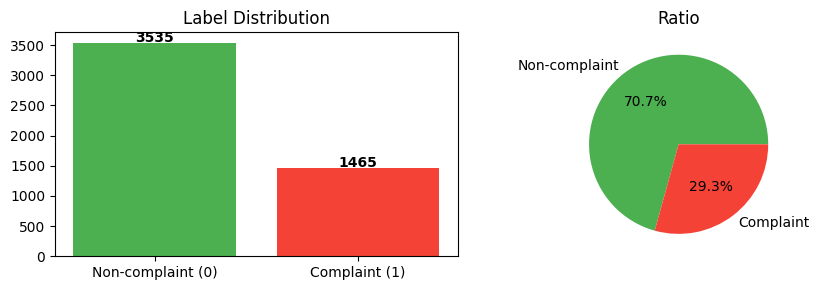

In [5]:
df = pd.read_csv(LABELED_CSV)
df.columns = df.columns.str.strip().str.lower()
print(f'Shape: {df.shape}')
print('Columns:', df.columns.tolist())

if 'quality_complaint' in df.columns:
    LABEL_COL = 'quality_complaint'
elif 'label' in df.columns:
    LABEL_COL = 'label'
else:
    raise ValueError('Không tìm thấy cột nhãn (quality_complaint / label)')

vc = df[LABEL_COL].value_counts().sort_index()
print(f'\nLabel distribution ({LABEL_COL}):')
print(vc)
print(f'Imbalance ratio: {vc[0]/vc[1]:.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(['Non-complaint (0)', 'Complaint (1)'], vc.values, color=['#4CAF50','#F44336'])
axes[0].set_title('Label Distribution')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=['Non-complaint','Complaint'],
            autopct='%1.1f%%', colors=['#4CAF50','#F44336'])
axes[1].set_title('Ratio')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## A2. Tiền xử lý văn bản

In [6]:
def preprocess(title, text):
    t = str(title) if pd.notna(title) else ''
    b = str(text)  if pd.notna(text)  else ''
    combined = (t + ' ' + b).strip()
    combined = re.sub(r'\s+', ' ', combined)
    return combined

titles = df['title'].fillna('').astype(str)
texts  = df['text'].fillna('').astype(str)

df['model_text'] = (titles + ' ' + texts).str.strip()
df['model_text'] = df['model_text'].str.replace(r'\s+', ' ', regex=True)

df = df[df['model_text'].str.len() > 5].reset_index(drop=True)

print(f'Sau tiền xử lý: {df.shape}')

Sau tiền xử lý: (4996, 6)


## A3. Train / Val / Test split (70 / 15 / 15)

In [7]:
X = df['model_text'].values
y = df[LABEL_COL].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'Train {len(X_train)} | Val {len(X_val)} | Test {len(X_test)}')
print(f'Complaint ratio — Train:{y_train.mean():.3f}  Val:{y_val.mean():.3f}  Test:{y_test.mean():.3f}')

Train 3497 | Val 749 | Test 750
Complaint ratio — Train:0.293  Val:0.294  Test:0.293


## A4. TF-IDF Vectorizer

In [8]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=100_000,
    sublinear_tf=True
)
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)
print(f'Vocab size: {len(tfidf.vocabulary_):,} | Train matrix: {X_train_vec.shape}')

Vocab size: 14,023 | Train matrix: (3497, 14023)


## A5. Hàm đánh giá

In [9]:
def find_best_threshold(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    denom = precision + recall
    f1 = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
    idx = np.argmax(f1[:-1])
    return float(thresholds[idx]), float(f1[idx])


def evaluate(y_true, probs, threshold, model_name='Model', save_fig=True):
    preds = (probs >= threshold).astype(int)
    metrics = {
        'F1':        f1_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall':    recall_score(y_true, preds),
        'AUC-ROC':   roc_auc_score(y_true, probs),
        'AP':        average_precision_score(y_true, probs),
        'Threshold': threshold
    }
    print(f'\n{"="*50}')
    print(model_name)
    print(f'{"="*50}')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    print()
    print(classification_report(y_true, preds, target_names=['Non-complaint','Complaint']))
    if save_fig:
        cm = confusion_matrix(y_true, preds)
        fig, ax = plt.subplots(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-complaint','Complaint'],
                    yticklabels=['Non-complaint','Complaint'], ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'Confusion Matrix — {model_name}')
        plt.tight_layout()
        fname = model_name.replace(' ','_').replace('—','').strip()
        plt.savefig(f'{OUTPUT_DIR}/cm_{fname}.png', dpi=120)
        plt.show()
    return metrics

## A6. Baseline 1 — TF-IDF + Logistic Regression

Best threshold LR: 0.507  (F1 val = 0.7435)

Logistic Regression
  F1          : 0.7435
  Precision   : 0.7125
  Recall      : 0.7773
  AUC-ROC     : 0.8999
  AP          : 0.8011
  Threshold   : 0.5071

               precision    recall  f1-score   support

Non-complaint       0.90      0.87      0.89       529
    Complaint       0.71      0.78      0.74       220

     accuracy                           0.84       749
    macro avg       0.81      0.82      0.81       749
 weighted avg       0.85      0.84      0.84       749



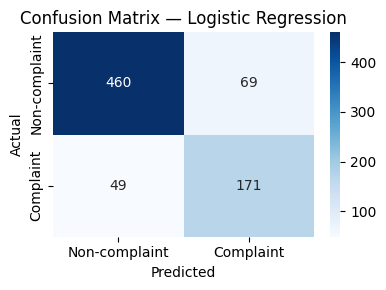

In [10]:
lr = LogisticRegression(
    class_weight='balanced', C=1.0,
    max_iter=1000, solver='lbfgs', random_state=SEED
)
lr.fit(X_train_vec, y_train)

probs_lr     = lr.predict_proba(X_val_vec)[:, 1]
th_lr, f1_lr = find_best_threshold(y_val, probs_lr)
print(f'Best threshold LR: {th_lr:.3f}  (F1 val = {f1_lr:.4f})')

res_lr = evaluate(y_val, probs_lr, th_lr, model_name='Logistic Regression')

## A7. Baseline 2 — TF-IDF + Linear SVM (Calibrated)

Best threshold SVM: 0.417  (F1 val = 0.7596)

Linear SVM
  F1          : 0.7596
  Precision   : 0.7511
  Recall      : 0.7682
  AUC-ROC     : 0.9119
  AP          : 0.8356
  Threshold   : 0.4168

               precision    recall  f1-score   support

Non-complaint       0.90      0.89      0.90       529
    Complaint       0.75      0.77      0.76       220

     accuracy                           0.86       749
    macro avg       0.83      0.83      0.83       749
 weighted avg       0.86      0.86      0.86       749



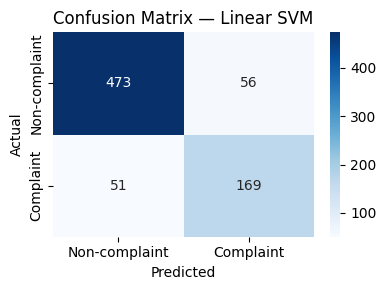

In [11]:
svm     = LinearSVC(class_weight='balanced', C=1.0, max_iter=2000, random_state=SEED)
svm_cal = CalibratedClassifierCV(svm, method='sigmoid', cv=5)
svm_cal.fit(X_train_vec, y_train)

probs_svm      = svm_cal.predict_proba(X_val_vec)[:, 1]
th_svm, f1_svm = find_best_threshold(y_val, probs_svm)
print(f'Best threshold SVM: {th_svm:.3f}  (F1 val = {f1_svm:.4f})')

res_svm = evaluate(y_val, probs_svm, th_svm, model_name='Linear SVM')

## A8. So sánh & Chọn model tốt nhất


=== BASELINE COMPARISON (Validation) ===
                         F1  Precision  Recall  AUC-ROC      AP  Threshold
Logistic Regression  0.7435     0.7125  0.7773   0.8999  0.8011     0.5071
Linear SVM           0.7596     0.7511  0.7682   0.9119  0.8356     0.4168


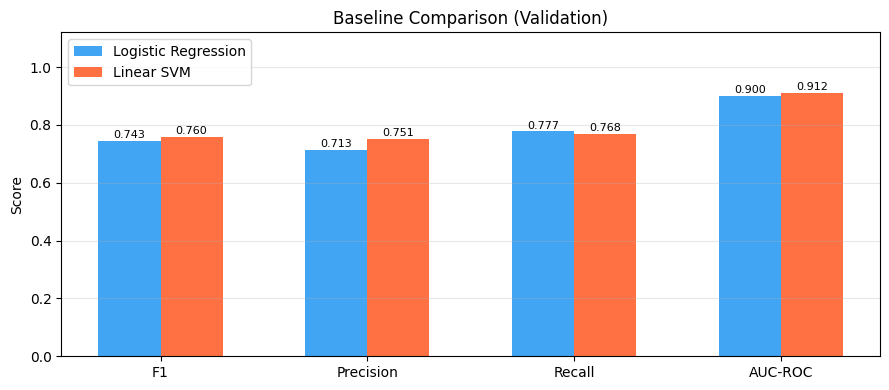


 BEST BASELINE: Linear SVM  (F1 val = 0.7596)


In [12]:
  print('\n=== BASELINE COMPARISON (Validation) ===')
  print(summary.to_string())

  metrics_plot = ['F1','Precision','Recall','AUC-ROC']
  x, w = np.arange(4), 0.3
  fig, ax = plt.subplots(figsize=(9, 4))
  ax.bar(x-w/2, [res_lr[m]  for m in metrics_plot], w, label='Logistic Regression', color='#2196F3', alpha=0.85)
  ax.bar(x+w/2, [res_svm[m] for m in metrics_plot], w, label='Linear SVM',          color='#FF5722', alpha=0.85)
  ax.set_xticks(x); ax.set_xticklabels(metrics_plot)
  ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
  ax.set_title('Baseline Comparison (Validation)')
  ax.legend(); ax.grid(axis='y', alpha=0.3)
  for bar in ax.patches:
      ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
              f'{bar.get_height():.3f}', ha='center', fontsize=8)
  plt.tight_layout()
  plt.savefig(f'{OUTPUT_DIR}/baseline_comparison.png', dpi=120)
  plt.show()

  if res_svm['F1'] >= res_lr['F1']:
      BEST_MODEL, BEST_THRESHOLD, BEST_NAME = svm_cal, th_svm, 'Linear SVM'
  else:
      BEST_MODEL, BEST_THRESHOLD, BEST_NAME = lr, th_lr, 'Logistic Regression'

  print(f'\n BEST BASELINE: {BEST_NAME}  (F1 val = {max(res_svm["F1"], res_lr["F1"]):.4f})')

## A9. DistilBERT Fine-tuning (GPU only)

In [13]:
TRAIN_BERT = torch.cuda.is_available()
print(f'Train BERT: {TRAIN_BERT}  (device: {device})')
if not TRAIN_BERT:
    print('  Không có GPU — bỏ qua DistilBERT, dùng best baseline.')

Train BERT: False  (device: cpu)
  Không có GPU — bỏ qua DistilBERT, dùng best baseline.


In [14]:
if TRAIN_BERT:
    from datasets import Dataset
    from transformers import (
        DistilBertTokenizerFast, DistilBertForSequenceClassification,
        TrainingArguments, Trainer, EarlyStoppingCallback
    )
    import torch.nn as nn
    import torch.nn.functional as F

    tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

    def make_hf_dataset(X_arr, y_arr):
        ds = Dataset.from_pandas(pd.DataFrame({'text': X_arr, 'label': y_arr.astype(int)}))
        def tok(batch):
            return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=256)
        ds = ds.map(tok, batched=True)
        ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])
        return ds

    train_ds = make_hf_dataset(X_train, y_train)
    val_ds   = make_hf_dataset(X_val,   y_val)

    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f'Pos weight: {pos_weight:.2f}')

    model_bert = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2
    ).to(device)

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop('labels').long()
            outputs = model(**inputs)
            weights = torch.tensor([1.0, float(pos_weight)], device=device, dtype=torch.float32)
            loss = nn.CrossEntropyLoss(weight=weights)(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return {'f1': f1_score(labels, preds)}

    args = TrainingArguments(
        output_dir=f'{OUTPUT_DIR}/bert_checkpoints',
        num_train_epochs=4,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        fp16=True,
        seed=SEED,
        report_to='none'
    )

    trainer = WeightedTrainer(
        model=model_bert, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    trainer.train()

    # Threshold trên val
    model_bert.eval()
    all_probs = []
    for i in range(0, len(val_ds), 64):
        batch = val_ds[i:i+64]
        with torch.no_grad():
            out = model_bert(input_ids=batch['input_ids'].to(device),
                             attention_mask=batch['attention_mask'].to(device))
        all_probs.append(F.softmax(out.logits, dim=1)[:,1].cpu().numpy())
    probs_bert = np.concatenate(all_probs)
    th_bert, f1_bert = find_best_threshold(y_val, probs_bert)

    res_bert = evaluate(y_val, probs_bert, th_bert, model_name='DistilBERT')

    if res_bert['F1'] > max(res_lr['F1'], res_svm['F1']):
        BEST_MODEL, BEST_THRESHOLD, BEST_NAME = model_bert, th_bert, 'DistilBERT'
        print(f'\n DistilBERT wins! F1={res_bert["F1"]:.4f}')
    else:
        print(f'\n Best baseline ({BEST_NAME}) still wins.')

## A10. Đánh giá trên Test set


Linear SVM — Test
  F1          : 0.7686
  Precision   : 0.7395
  Recall      : 0.8000
  AUC-ROC     : 0.9207
  AP          : 0.8377
  Threshold   : 0.4168

               precision    recall  f1-score   support

Non-complaint       0.91      0.88      0.90       530
    Complaint       0.74      0.80      0.77       220

     accuracy                           0.86       750
    macro avg       0.83      0.84      0.83       750
 weighted avg       0.86      0.86      0.86       750



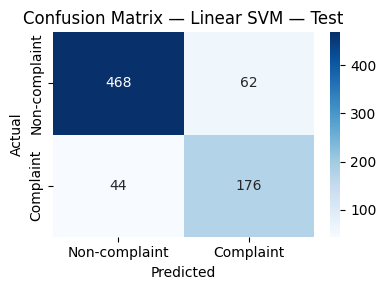


 Final model: Linear SVM  |  Test F1: 0.7686


In [15]:
if BEST_NAME == 'DistilBERT':
    test_ds = make_hf_dataset(X_test, y_test)
    all_probs = []
    model_bert.eval()
    for i in range(0, len(test_ds), 64):
        batch = test_ds[i:i+64]
        with torch.no_grad():
            out = model_bert(input_ids=batch['input_ids'].to(device),
                             attention_mask=batch['attention_mask'].to(device))
        all_probs.append(F.softmax(out.logits, dim=1)[:,1].cpu().numpy())
    probs_test = np.concatenate(all_probs)
else:
    probs_test = BEST_MODEL.predict_proba(X_test_vec)[:, 1]

res_test = evaluate(y_test, probs_test, BEST_THRESHOLD, model_name=f'{BEST_NAME} — Test')
print(f'\n Final model: {BEST_NAME}  |  Test F1: {res_test["F1"]:.4f}')

## A11. Lưu model & artifacts

In [16]:
joblib.dump(tfidf, f'{OUTPUT_DIR}/tfidf_vectorizer.pkl')

if BEST_NAME != 'DistilBERT':
    joblib.dump(BEST_MODEL, f'{OUTPUT_DIR}/complaint_classifier.pkl')
    print('Saved: tfidf_vectorizer.pkl, complaint_classifier.pkl')
else:
    trainer.save_model(f'{OUTPUT_DIR}/bert_model')
    tokenizer.save_pretrained(f'{OUTPUT_DIR}/bert_model')
    print('Saved: tfidf_vectorizer.pkl, bert_model/')

joblib.dump({'model': BEST_NAME, 'threshold': BEST_THRESHOLD},
            f'{OUTPUT_DIR}/model_config.pkl')
print('Saved: model_config.pkl')
print(f'\nConfig: model={BEST_NAME}, threshold={BEST_THRESHOLD:.4f}')

Saved: tfidf_vectorizer.pkl, complaint_classifier.pkl
Saved: model_config.pkl

Config: model=Linear SVM, threshold=0.4168


---
# PHẦN B — INFERENCE TRÊN PARQUET PHÂN VÙNG



## B1. Load parquet phân vùng & kiểm tra

In [17]:
path_pattern = os.path.join(INFER_PARQUET, "**/*.parquet")

all_part_files = sorted([
    f for f in glob.glob(path_pattern, recursive=True)
    if os.path.isfile(f) and os.path.basename(f).startswith("part-")
])

if not all_part_files:
    raise FileNotFoundError(f"Không tìm thấy file part-*.parquet nào tại {INFER_PARQUET}")

def extract_part_num(path):
    match = re.search(r'part-(\d+)', path)
    return int(match.group(1)) if match else -1

all_part_files = sorted(all_part_files, key=extract_part_num)

print(f" Tìm thấy {len(all_part_files)} file part parquet.")
print(" Sample files:")
for f in all_part_files[:5]:
    print("  ", f)

 Tìm thấy 60 file part parquet.
 Sample files:
   /content/drive/MyDrive/KPDL/clean_reviews/clean_reviews.parquet-20260415T220352Z-3-004/clean_reviews.parquet/part-00000-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
   /content/drive/MyDrive/KPDL/clean_reviews/clean_reviews.parquet-20260415T220352Z-3-004/clean_reviews.parquet/part-00001-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
   /content/drive/MyDrive/KPDL/clean_reviews/clean_reviews.parquet-20260415T220352Z-3-004/clean_reviews.parquet/part-00002-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
   /content/drive/MyDrive/KPDL/clean_reviews/clean_reviews.parquet-20260415T220352Z-3-003/clean_reviews.parquet/part-00003-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
   /content/drive/MyDrive/KPDL/clean_reviews/clean_reviews.parquet-20260415T220352Z-3-004/clean_reviews.parquet/part-00004-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet


## B2. Inference theo batch 

In [18]:
def infer_sklearn_batch(texts, model, vectorizer, threshold, batch_size=100_000):
    all_probs = []
    total = len(texts)
    for start in range(0, total, batch_size):
        end  = min(start + batch_size, total)
        vecs = vectorizer.transform(texts[start:end])
        all_probs.append(model.predict_proba(vecs)[:, 1])
        print(f'  Processed {end:,} / {total:,}', end='\r')
    print()
    probs_all = np.concatenate(all_probs)
    return probs_all, (probs_all >= threshold).astype(int)

BEST_MODEL = lr   
BEST_THRESHOLD = th_lr

# Vòng lặp xử lý từng file 
final_results = []

for i, f_path in enumerate(all_part_files):
    print(f"\n[{i+1}/{len(all_part_files)}] Processing: {os.path.basename(f_path)}")

    try:
        df_chunk = pd.read_parquet(f_path)
    except Exception as e:
        print(f" Error reading file: {e}")
        continue

    print(f"  Loaded: {df_chunk.shape}")

    titles = df_chunk['title'].fillna('') if 'title' in df_chunk.columns else ['']*len(df_chunk)
    texts  = df_chunk['text'].fillna('')  if 'text'  in df_chunk.columns else ['']*len(df_chunk)

    print("  Preprocessing...")
    df_chunk['model_text'] = [
        preprocess(t, x) for t, x in zip(titles, texts)
    ]

    df_chunk = df_chunk[df_chunk['model_text'].str.len() > 5].reset_index(drop=True)

    if len(df_chunk) == 0:
        print("  Skip empty chunk")
        continue

    texts_to_infer = df_chunk['model_text'].tolist()

    print("  Inference...")


    probs, labels = infer_sklearn_batch(
            texts_to_infer, BEST_MODEL, tfidf, BEST_THRESHOLD
        )

    df_chunk['complaint_prob']  = probs.round(4)
    df_chunk['complaint_label'] = labels

    df_chunk = df_chunk.drop(columns=['model_text'])

    out_path = f'{OUTPUT_DIR}/part_{i}.parquet'
    df_chunk.to_parquet(out_path, index=False)

    print(f"  Saved: {out_path}")

    del df_chunk, texts_to_infer

    torch.cuda.empty_cache()


[1/60] Processing: part-00000-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
  Loaded: (722220, 8)
  Preprocessing...
  Inference...
  Processed 721,313 / 721,313
  Saved: /content/drive/MyDrive/KPDL/outputs/part_0.parquet

[2/60] Processing: part-00001-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
  Loaded: (722220, 8)
  Preprocessing...
  Inference...
  Processed 721,296 / 721,296
  Saved: /content/drive/MyDrive/KPDL/outputs/part_1.parquet

[3/60] Processing: part-00002-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
  Loaded: (722221, 8)
  Preprocessing...
  Inference...
  Processed 721,333 / 721,333
  Saved: /content/drive/MyDrive/KPDL/outputs/part_2.parquet

[4/60] Processing: part-00003-5447ecee-fb4f-4738-bf0c-817cf630f694-c000.snappy.parquet
  Loaded: (722219, 8)
  Preprocessing...
  Inference...
  Processed 721,310 / 721,310
  Saved: /content/drive/MyDrive/KPDL/outputs/part_3.parquet

[5/60] Processing: part-00004-5447ecee-fb4f-4738-bf0c-817cf630f

## B3. Phân phối complaint

In [21]:
files = sorted(glob.glob(f'{OUTPUT_DIR}/part_*.parquet'))

# ===== Lấy sample  =====
dfs = []
for f in files[:10]: 
    df_tmp = pd.read_parquet(f)
    dfs.append(df_tmp.sample(50000))  

df_plot = pd.concat(dfs, ignore_index=True)

print("Sample shape:", df_plot.shape)

Sample shape: (500000, 10)


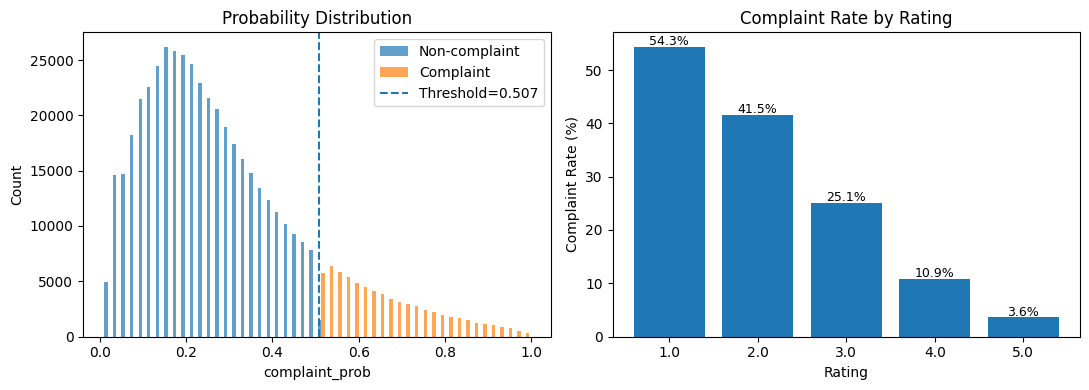

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ===== Histogram =====
axes[0].hist(
    [df_plot[df_plot['complaint_label']==0]['complaint_prob'],
     df_plot[df_plot['complaint_label']==1]['complaint_prob']],
    bins=50,
    label=['Non-complaint','Complaint'],
    alpha=0.7
)
axes[0].axvline(BEST_THRESHOLD, linestyle='--',
                label=f'Threshold={BEST_THRESHOLD:.3f}')
axes[0].set_xlabel('complaint_prob')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution')
axes[0].legend()

# ===== Complaint rate theo rating =====
if 'rating' in df_plot.columns:
    cr = df_plot.groupby('rating')['complaint_label'].mean() * 100
    cr = cr.sort_index()

    axes[1].bar(cr.index.astype(str), cr.values)
    axes[1].set_xlabel('Rating')
    axes[1].set_ylabel('Complaint Rate (%)')
    axes[1].set_title('Complaint Rate by Rating')

    for i, v in enumerate(cr.values):
        axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/infer_distribution.png', dpi=120)
plt.show()